## Is Customer Revenue Normally Distributed?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_customer = pd.read_csv('../data/processed/online_retail_with_customer.csv')
df_customer['InvoiceDate'] = pd.to_datetime(df_customer['InvoiceDate'])

customer_revenue = df_customer.groupby('Customer ID')['Revenue'].sum()

print("Skewness:", customer_revenue.skew())
print("Kurtosis:", customer_revenue.kurtosis())

Skewness: 25.330433272114707
Kurtosis: 849.4486378497514


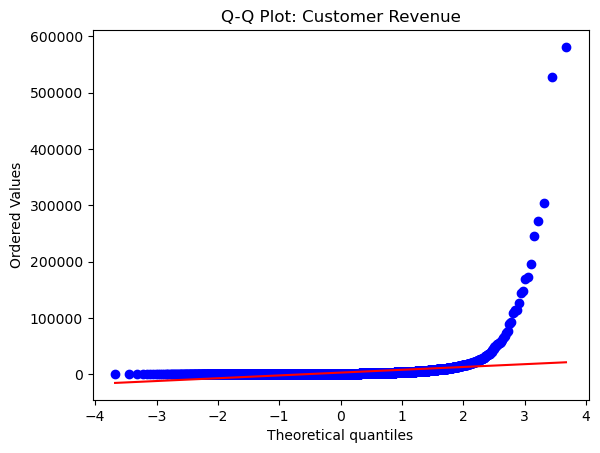

In [2]:
stats.probplot(customer_revenue, plot=plt)
plt.title('Q-Q Plot: Customer Revenue')
plt.show()

In [3]:
#Standardize customer revenue
standardized_revenue = (customer_revenue - customer_revenue.mean()) / customer_revenue.std()

#Kolmogorov-Smirnov test for normality
ks_stat, ks_p_value = stats.kstest(standardized_revenue, 'norm')

print(f"KS statistic: {ks_stat:.4f}")
print(f"P-value: {ks_p_value:.4f}")

if ks_p_value < 0.05:
     print("Customer revenue is significantly different from a normal distribution.")
else:
    print("Customer revenue is not significantly different from a normal distribution.")

KS statistic: 0.4193
P-value: 0.0000
Customer revenue is significantly different from a normal distribution.


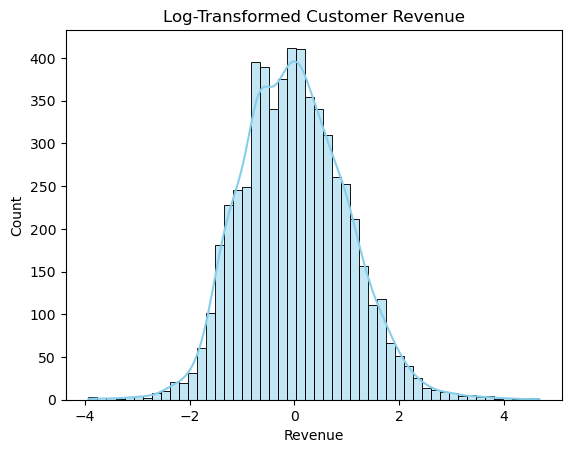

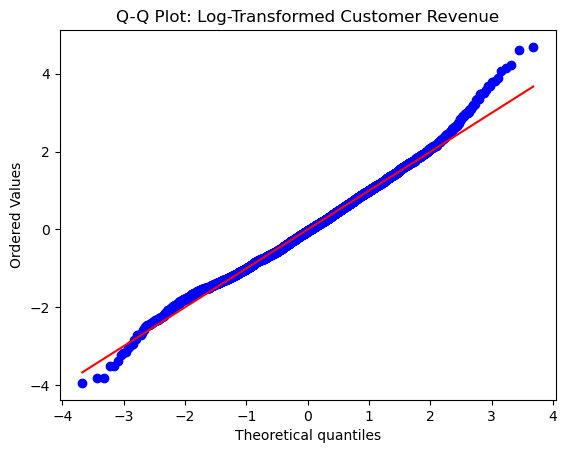

KS statistic: 0.0229, p-value: 0.004189493477562108


In [4]:
# Log transformation
log_revenue = np.log1p(customer_revenue)
standardized_log_revenue = (log_revenue - log_revenue.mean()) / log_revenue.std()

sns.histplot(standardized_log_revenue, kde=True, bins=50, color="skyblue")
plt.title('Log-Transformed Customer Revenue')
plt.show()

stats.probplot(standardized_log_revenue, plot=plt)
plt.title('Q-Q Plot: Log-Transformed Customer Revenue')
plt.show()

ks_stat_log, ks_p_log = stats.kstest(standardized_log_revenue, 'norm')
print(f"KS statistic: {ks_stat_log:.4f}, p-value: {ks_p_log}")

Customer Revenue is extremley non normal(skewness=25.33, kurtosis=849.45),
confirmed by a Kolmogorov-Smirnov test (p<0.0001). A log transformation greatly improved this (KS statistic dropped from 0.42 to 0.02), but the data is still technically non normal(p=0.0042) because of few extreme high value customers. This supports the RQ2 finding that a small group og very high value cusotmers behaves very differently from the rest, worth keeping in mind for any future statistical modelling.

## Frequency vs Monetary Value

### Hypotheses

**H0:** There is no significant association between customer purchase
frequency and monetary value.

**H1:** There is a significant association between customer purchase
frequency and monetary value.

Significance level: α = 0.05

In [5]:
# Create customer level features for the correlation test

customer_features = df_customer.groupby('Customer ID').agg(
    Monetary=('Revenue', 'sum'),
    Frequency=('Invoice', 'nunique')
)

customer_features.head()

,Monetary,Frequency
Customer ID,,
12346,77556.46,12
12347,4921.53,8
12348,1658.40,5
12349,3678.69,3
12350,294.40,1


In [6]:
# using Spearman Correlation 

from scipy.stats import spearmanr

correlation_coef, p_value = spearmanr(
    customer_features['Frequency'],
    customer_features['Monetary']
)

print(f"Spearman Correlation: {correlation_coef:.4f}")
print(f"P-value: {p_value:.2e}")

alpha = 0.05

if p_value < alpha:
    print("We reject the null hypothesis.")
else:
    print("We fail to reject the null hypothesis.")

Spearman Correlation: 0.8592
P-value: 0.00e+00
We reject the null hypothesis.


## Result
The Spearman correlation between purchase frequency and customer monetary value 
is **0.859**, indicating a strong positive association between the two variables.

The p-value is below 0.05, so we reject the null hypothesis. There is statistically 
significant evidence of an association between how frequently customers purchase 
and the total revenue they generate.

### Business Insight

Frequent customers tend to be substantially more valuable to the business. This 
suggests that customer retention and repeat-purchase strategies could play an 
important role in increasing customer value.

However, correlation does not establish causation, so the result should be 
interpreted as an association rather than evidence that increasing purchase 
frequency alone will necessarily cause higher customer spending.

## Is Cancellation Associated with Product Category? 

### Hypotheses

**H0:** Product category and cancellation status are independent.

**H1:** Product category and cancellation status are associated.

Significance level: α = 0.05

In [7]:
# using Chi-Square Test
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

df_sales = pd.read_csv('../data/processed/online_retail_cleaned.csv')
df_cancellations = pd.read_csv('../data/processed/cancellations.csv')

df_sales['is_cancelled'] = False
df_cancellations['is_cancelled'] = True
all_transactions = pd.concat([df_sales, df_cancellations], ignore_index=True)

crosstab_result = pd.crosstab(all_transactions['Category'], all_transactions['is_cancelled'])
print(crosstab_result)

chi2_statistic, chi2_p_value, _, _ =chi2_contingency(crosstab_result)
print(f"\nChi-square statistic: {chi2_statistic:.2f}")
print(f"P-value:{chi2_p_value}")

cramers_v = association(crosstab_result, method="cramer")
print(f"Cramer's V: {cramers_v:.4f}")

is_cancelled               False  True 
Category                               
Bags & Storage             99618   1392
Christmas & Seasonal       43692    577
Craft & Textile            15700    147
Garden & Outdoor           33043    408
Hardware & Fixtures         7458    185
Home Decor & Lighting     186341   4076
Kitchen & Dining          212584   5363
Novelty & Personal Items   50111    787
Novelty Signs              53454    553
Other                      95396   2716
Party & Occasion           27143    302
Stationery & Gift Wrap     74419    639
Storage & Boxes            82660   2040
Toys & Kids Craft          21828    309

Chi-square statistic: 2164.97
P-value:0.0
Cramer's V: 0.0460


## Result

The Chi-square test produced a statistic of **2164.97** with a p-value below 
0.001. Therefore, we reject the null hypothesis and conclude that there is a 
statistically significant association between product category and cancellation 
status.

However, **Cramer's V is only 0.046**, indicating that the strength of the 
association is very weak.

### Business Insight

Cancellation rates vary across product categories, but product category alone 
does not appear to be a strong factor in explaining cancellations.

Therefore, cancellation-reduction strategies should not focus only on product 
categories. Other factors, such as customer purchasing behavior and order 
characteristics, should also be investigated.

## Order Value: Customers With Cancelations vs. Without 

### Hypotheses

**H0:** There is no significant difference in average order value
between customers who have cancelled and customers who have never cancelled.

**H1:** There is a significant difference in average order value
between customers who have cancelled and customers who have never cancelled.

Significance level: α = 0.05

In [8]:
#using Two-Sample T-Test
from scipy import stats as st

#identify customers have ever had a cancellation
cancelling_customer_ids = set(df_cancellations['Customer ID'].dropna())

df_customer['has_cancelled'] = df_customer['Customer ID'].isin(cancelling_customer_ids)

#average order value per customer (completed ones only)
order_value_per_invoice = df_customer.groupby(['Customer ID', 'Invoice'])['Revenue'].sum().reset_index()
order_value_per_invoice = order_value_per_invoice.merge(
    df_customer[['Customer ID', 'has_cancelled']].drop_duplicates(), on='Customer ID'
)

group_cancelled = order_value_per_invoice[order_value_per_invoice['has_cancelled'] == True]['Revenue']
group_not_cancelled = order_value_per_invoice[order_value_per_invoice['has_cancelled'] == False]['Revenue']

print(f"Customers who have cancelled: mean order value = £{group_cancelled.mean():.2f}, n = {len(group_cancelled)}")
print(f"Customers who never cancelled: mean order value = £{group_not_cancelled.mean():.2f}, n = {len(group_not_cancelled)}")

Customers who have cancelled: mean order value = £521.72, n = 26740
Customers who never cancelled: mean order value = £316.10, n = 9864


In [9]:
result = st.ttest_ind(group_cancelled, group_not_cancelled, equal_var=False)
print(result)

alpha = 0.05
if result.pvalue > alpha:
    print("We fail to reject the null hypothesis")
else:
    print("We reject the null hypothesis")

TtestResult(statistic=np.float64(19.666139573073036), pvalue=np.float64(1.2384996596351122e-85), df=np.float64(34548.4231160148))
We reject the null hypothesis


## Result:
Customers with a cancellation history had a significantly higher average order value (£521.72) than custoemrs who never cancelled (£316.10).

The difference is statistically significant (p , 0.001), so we reject the null hypothesis.

## Business Insight:
Higher value customers appear more likely to have a cancellation history, making them an important group for cancellation monitoring and retention strategies.